In [1]:
from pymatgen.analysis.wulff import WulffShape
from pymatgen.core import Lattice
import matplotlib.pyplot as plt

# Mg21Zn25 hexagonal lattice (R-3c in hexagonal setting)
a = 26.121
c = 8.788
lattice = Lattice.hexagonal(a, c)

print(f"Lattice: a={lattice.a:.3f}, c={lattice.c:.3f}")
print(f"Angles: {lattice.alpha:.1f}, {lattice.beta:.1f}, {lattice.gamma:.1f}")

miller_indices = [
    (0, 0, 1),
    (1, 0, 0),
    (1, 0, 1),
    (1, 1, 0),
    (2, 0, 1),
]

surface_energies = [
    0.5946,  # (001)
    0.6451,  # (100)
    0.6200,  # (101)
    0.6676,  # (110)
    0.6184,  # (201)
]

wulff = WulffShape(lattice, miller_indices, surface_energies)

print(f"\nWulff shape summary:")
print(f"  Weighted surface energy: {wulff.weighted_surface_energy:.4f} J/m²")
print(f"  Anisotropy: {wulff.anisotropy:.4f}")
print(f"  Shape factor: {wulff.shape_factor:.4f}")

print(f"\n  {'Plane':>8} {'γ (J/m²)':>10} {'Area frac':>10}")
print("  " + "-" * 32)
for facet, energy in zip(miller_indices, surface_energies):
    area_frac = wulff.area_fraction_dict.get(tuple(facet), 0)
    print(f"  {str(facet):>8} {energy:>10.4f} {area_frac:>10.4f}")

Lattice: a=26.121, c=8.788
Angles: 90.0, 90.0, 120.0

Wulff shape summary:
  Weighted surface energy: 0.6327 J/m²
  Anisotropy: 0.0320
  Shape factor: 5.0758

     Plane   γ (J/m²)  Area frac
  --------------------------------
  (0, 0, 1)     0.5946     0.0393
  (1, 0, 0)     0.6451     0.2534
  (1, 0, 1)     0.6200     0.0757
  (1, 1, 0)     0.6676     0.1701
  (2, 0, 1)     0.6184     0.4615


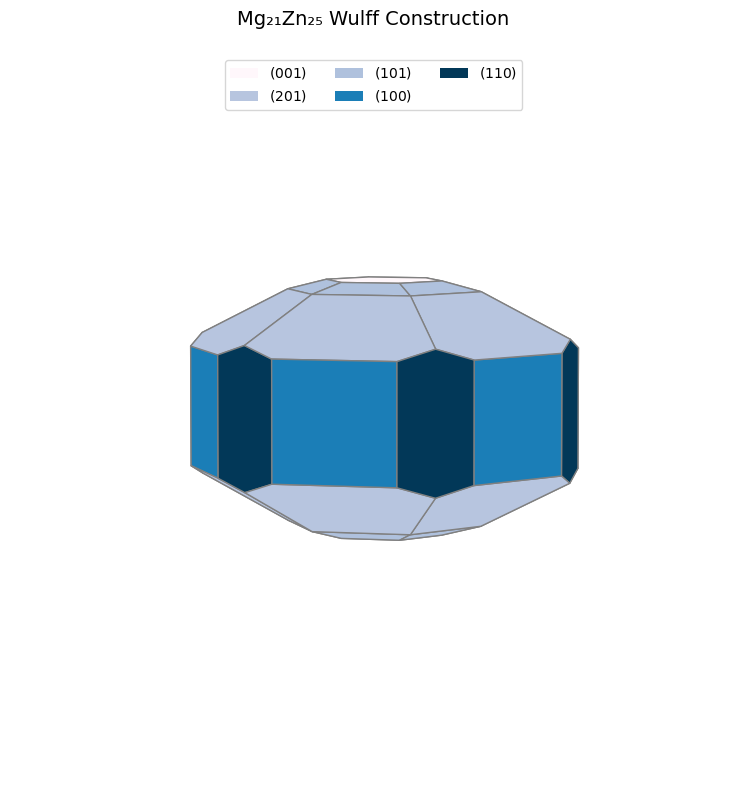

In [4]:
ax = wulff.get_plot()
fig = ax.get_figure()
fig.set_size_inches(8, 8)
ax.view_init(elev=5, azim=45)
plt.title("Mg₂₁Zn₂₅ Wulff Construction", fontsize=14, pad=20)
plt.tight_layout()
plt.show()